Mounting your Google Drive for Google Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Using three essential Python libraries.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files

# Make matplotlib show images inline
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


Uploading the input image.

In [14]:
from google.colab import files
uploaded = files.upload()

Saving Pomegranates.png to Pomegranates.png


Displaying the uploaded image.

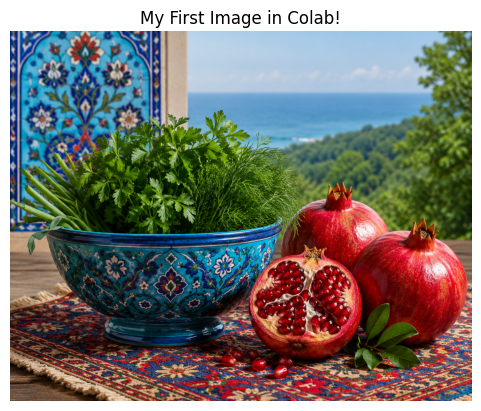

In [15]:
# Read the image
image_name = list(uploaded.keys())[0]  # Get the name of the uploaded file
image = cv2.imread(image_name)

# Convert BGR (OpenCV default) to RGB (Matplotlib default)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)
plt.title("My First Image in Colab!")
plt.axis('off')  # Turn off axes
plt.show()

Examining the fundamental properties of our image.

In [16]:
# Print image properties
print(f"Image shape: {image.shape}")
print(f"Image data type: {image.dtype}")
print(f"Number of pixels: {image.shape[0] * image.shape[1]}")

# For color images, shape = (height, width, channels)
if len(image.shape) == 3:
    height, width, channels = image.shape
    print(f"Height: {height} pixels")
    print(f"Width: {width} pixels")
    print(f"Number of color channels: {channels}")

# Access a specific pixel
row, col = 100, 150
pixel_bgr = image[row, col]
pixel_rgb = image_rgb[row, col]
print(f"\nPixel at ({row}, {col}):")
print(f"  BGR: {pixel_bgr}")
print(f"  RGB: {pixel_rgb}")

Image shape: (1122, 1402, 3)
Image data type: uint8
Number of pixels: 1573044
Height: 1122 pixels
Width: 1402 pixels
Number of color channels: 3

Pixel at (100, 150):
  BGR: [182 187 195]
  RGB: [195 187 182]


Separating the image into its three color channels and visualize each.

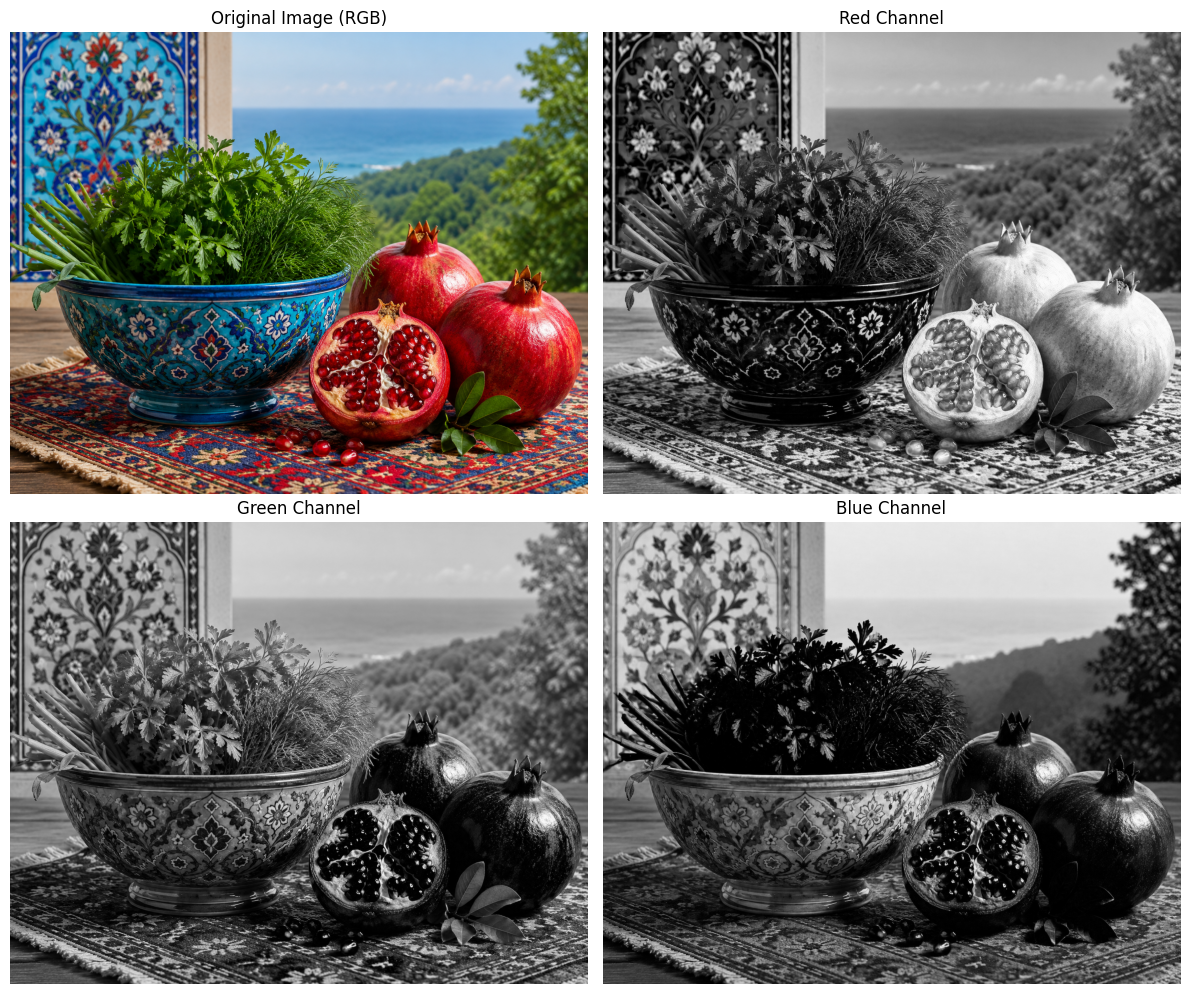

In [17]:
# Split the RGB image into channels
R = image_rgb[:, :, 0]  # Red channel
G = image_rgb[:, :, 1]  # Green channel
B = image_rgb[:, :, 2]  # Blue channel

# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original image
axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title('Original Image (RGB)')
axes[0, 0].axis('off')

# Red channel
axes[0, 1].imshow(R, cmap='gray')
axes[0, 1].set_title('Red Channel')
axes[0, 1].axis('off')

# Green channel
axes[1, 0].imshow(G, cmap='gray')
axes[1, 0].set_title('Green Channel')
axes[1, 0].axis('off')

# Blue channel
axes[1, 1].imshow(B, cmap='gray')
axes[1, 1].set_title('Blue Channel')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

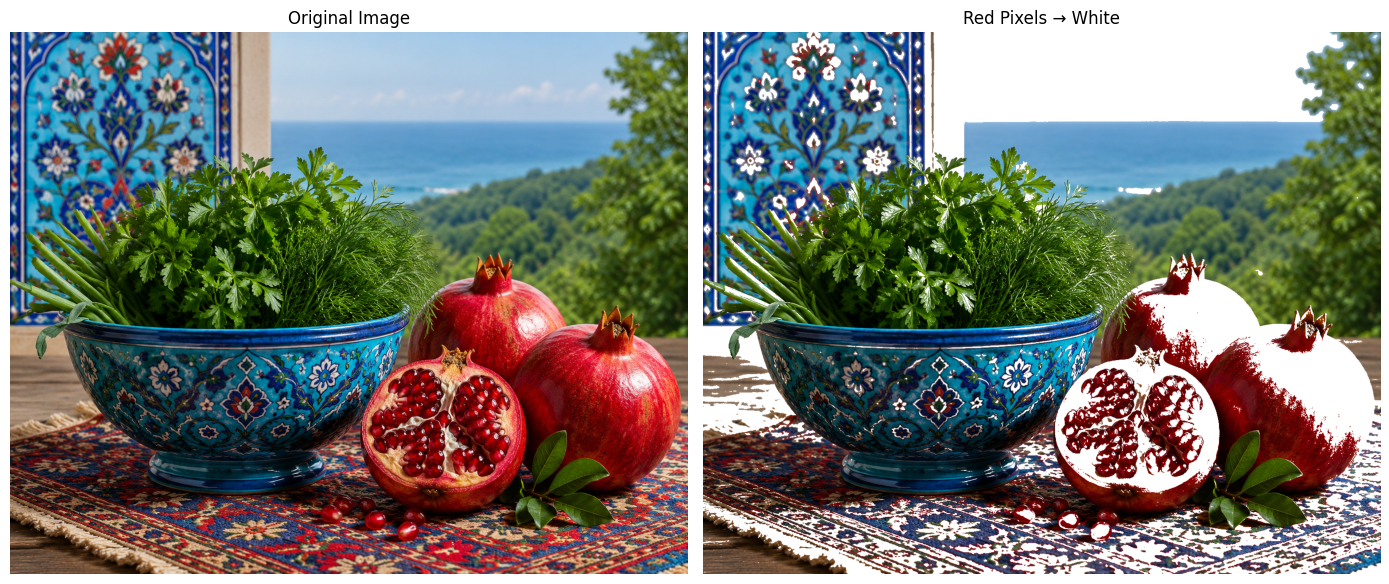

In [19]:
# Create a copy of the original image
modified = image_rgb.copy()

# Get the image dimensions
height, width, channels = modified.shape

# Apply the condition to every pixel
for i in range(height):
    for j in range(width):
        r, g, b = modified[i, j]
        if r > 150:  # If Red is very high
            modified[i, j] = [255, 255, 255]  # Turn to white

# Display original and modified side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(image_rgb)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(modified)
ax2.set_title('Red Pixels → White')
ax2.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print(image_rgb)

[[[ 60  66  20]
  [ 62  70  21]
  [ 72  85  32]
  ...
  [ 73  89  52]
  [ 63  79  42]
  [ 39  55  18]]

 [[ 62  68  22]
  [ 68  76  27]
  [ 81  94  41]
  ...
  [ 76  92  55]
  [ 66  82  45]
  [ 42  58  21]]

 [[ 68  74  28]
  [ 78  86  37]
  [ 97 110  57]
  ...
  [ 80  96  59]
  [ 71  87  50]
  [ 48  64  27]]

 ...

 [[ 91 111  83]
  [ 88 108  80]
  [ 85 105  77]
  ...
  [119 115  88]
  [102  98  71]
  [ 77  73  46]]

 [[106 126  98]
  [100 120  92]
  [ 90 110  82]
  ...
  [128 124  97]
  [111 107  80]
  [ 86  82  55]]

 [[105 125  97]
  [ 96 116  88]
  [ 82 102  74]
  ...
  [133 129 102]
  [116 112  85]
  [ 91  87  60]]]


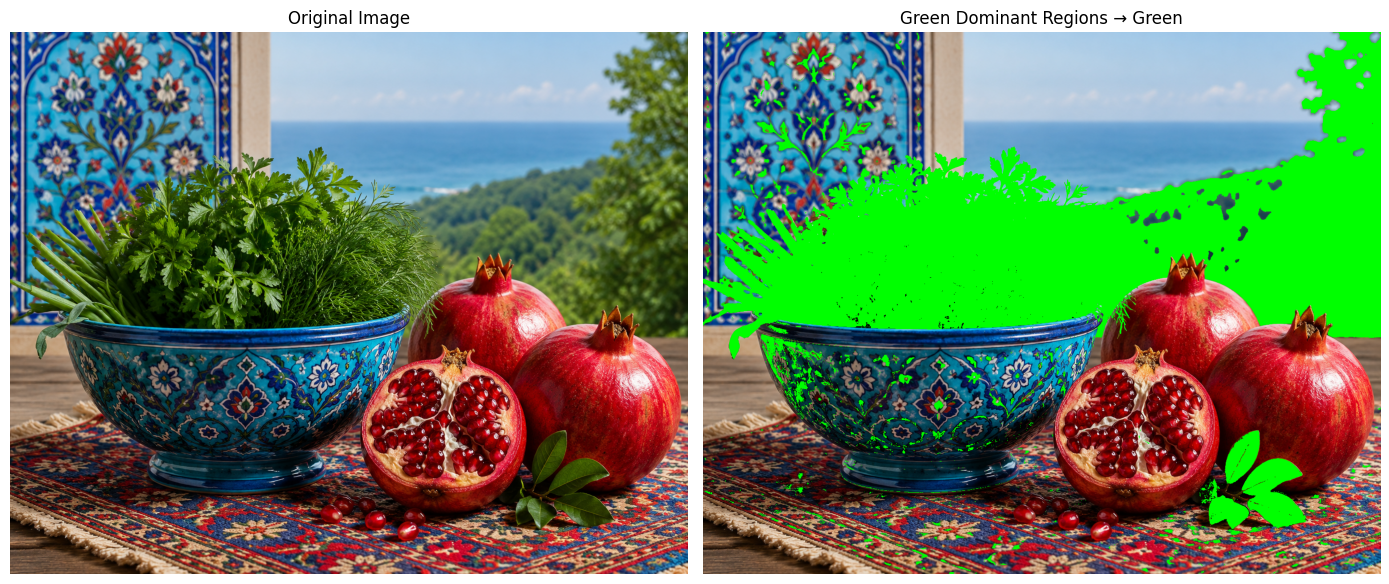

In [20]:
modified = image_rgb.copy()

for i in range(height):
    for j in range(width):
        r, g, b = modified[i, j]
        if g > r and g > b:  # Green dominates
            modified[i, j] = [0, 255, 0]  # Pure green

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(image_rgb)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(modified)
ax2.set_title('Green Dominant Regions → Green')
ax2.axis('off')

plt.tight_layout()
plt.show()

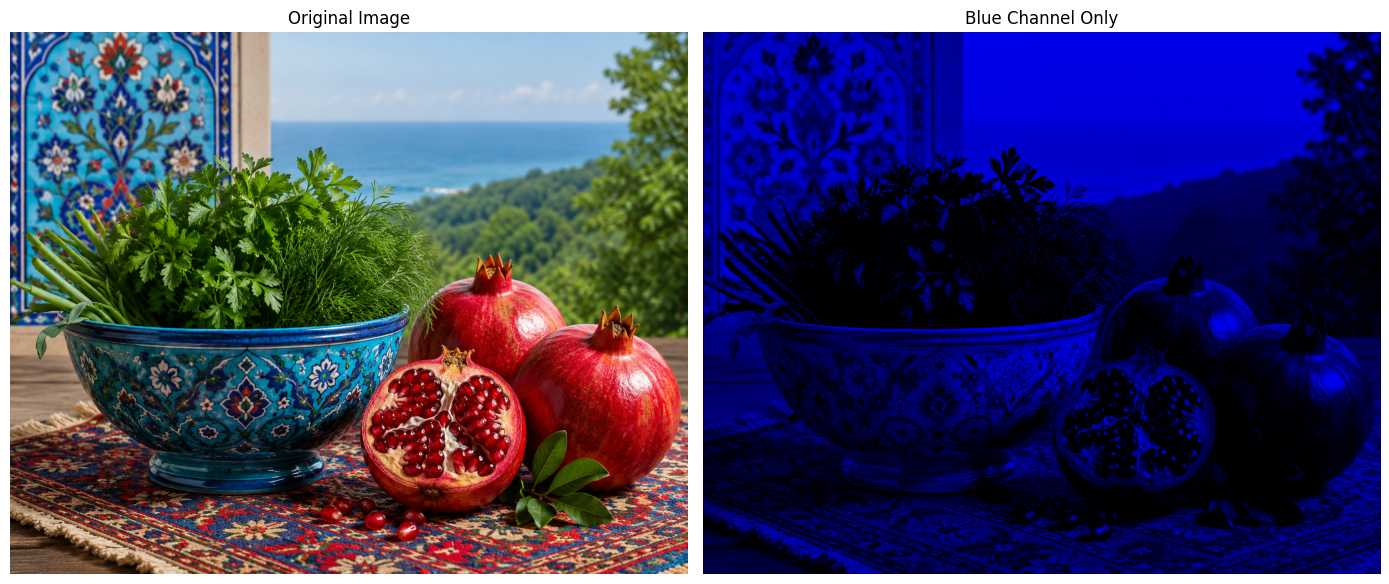

In [21]:
blue_only = image_rgb.copy()

for i in range(height):
    for j in range(width):
        # Set Red and Green channels to zero
        blue_only[i, j, 0] = 0  # Red = 0
        blue_only[i, j, 1] = 0  # Green = 0
        # Blue remains unchanged

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(image_rgb)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(blue_only)
ax2.set_title('Blue Channel Only')
ax2.axis('off')

plt.tight_layout()
plt.show()

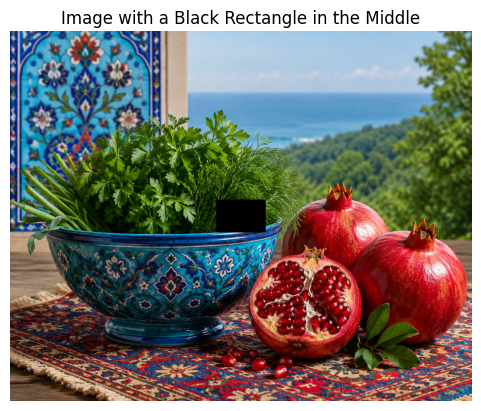

In [22]:
drawn = image_rgb.copy()

# Calculate the center of the image
center_h, center_w = height // 2, width // 2

# Rectangle dimensions
rect_h, rect_w = 100, 150

# Draw the rectangle
for i in range(center_h - rect_h//2, center_h + rect_h//2):
    for j in range(center_w - rect_w//2, center_w + rect_w//2):
        drawn[i, j] = [0, 0, 0]  # Black rectangle

plt.imshow(drawn)
plt.title('Image with a Black Rectangle in the Middle')
plt.axis('off')
plt.show()

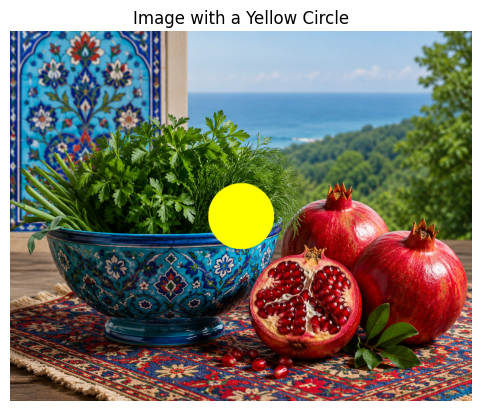

In [23]:
drawn = image_rgb.copy()

# Circle center and radius
circle_center = (width // 2, height // 2)
radius = 100

for i in range(height):
    for j in range(width):
        # Distance from center
        distance = np.sqrt((i - circle_center[1])**2 + (j - circle_center[0])**2)
        if distance <= radius:
            drawn[i, j] = [255, 255, 0]  # Yellow

plt.imshow(drawn)
plt.title('Image with a Yellow Circle')
plt.axis('off')
plt.show()

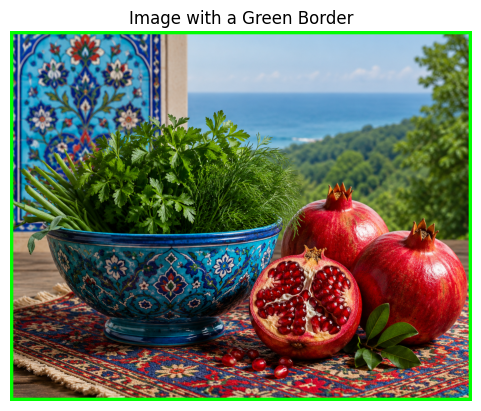

In [24]:
drawn = image_rgb.copy()
border_size = 10

for i in range(height):
    for j in range(width):
        # Check if pixel is on the border
        if i < border_size or i >= height - border_size or j < border_size or j >= width - border_size:
            drawn[i, j] = [0, 255, 0]  # Green

plt.imshow(drawn)
plt.title('Image with a Green Border')
plt.axis('off')
plt.show()

In [25]:
# Convert RGB back to BGR for OpenCV
output_image = cv2.cvtColor(drawn, cv2.COLOR_RGB2BGR)

# Save the image
output_filename = "modified_image.jpg"
cv2.imwrite(output_filename, output_image)

# Download the image
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>